# When working with linear regression, we used:
# $\hat{y} = wX + b$ as our predicting function
# **MSE** as our loss function:
#
# $$MSE = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$
#
# However, if we have a binary classification task and need to classify between 0 and 1, we should use:
# $\hat{y} = \dfrac{1}{1 + e^{-z}}$, where $z$ is a linear function (e.g. $z = wX + b$)
# **Cross-entropy loss** as our loss function:
#
# $$L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \right]$$

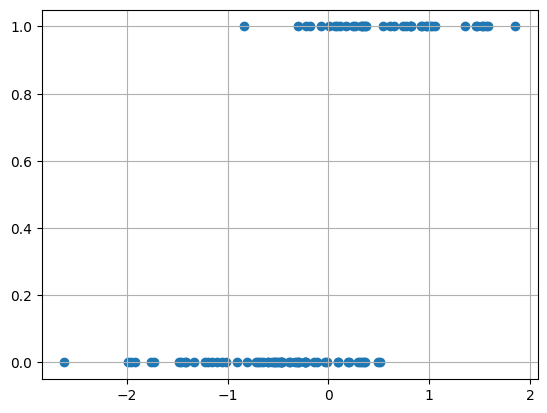

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.randn(100)
y = (X + np.random.randn(100) * 0.5 > 0).astype(float) # Generate 100 points, then round them to 0 or 1

plt.scatter(X, y)
plt.grid()
plt.show()

The **sigmoid function** squashes any real-valued input $z$ into the range $(0, 1)$, making it useful for binary classification:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

In [2]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

In [4]:
def compute_cross_entropy_loss(X, y, w, b):
  n = len(X)

  y_pred = sigmoid(w * X + b) # y_pred = 1 / (1 + e^(-(wX + b)))

  return (-1 / n) * np.sum( (y * np.log(y_pred) ) + ( (1 - y) * (np.log(1 - y_pred)) ) )

### Gradient Derivation

Prediction: $\hat{y} = \sigma(z)$, where $z = wX + b$

Loss: $L = -\frac{1}{n} \sum \left[ y \ln(\hat{y}) + (1 - y) \ln(1 - \hat{y}) \right]$

Using the chain rule: $\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}$

The key trick: sigmoid's derivative is $\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$, which cancels perfectly with the cross-entropy terms, leaving:

$$\frac{\partial L}{\partial z_i} = \frac{1}{n}(\hat{y}_i - y_i)$$

Then since $\frac{\partial z}{\partial w} = X$ and $\frac{\partial z}{\partial b} = 1$:

$$\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} X_i (\hat{y}_i - y_i)$$

$$\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)$$

In [5]:
def compute_gradients(X, y, w, b):

  n = len(X)
  y_pred = sigmoid(w * X + b)
  error = y_pred - y

  dw = (1/n) * np.dot(X, error)
  db = (1/n) * np.sum(error)

  return dw, db


Epoch 0
Current loss: 0.5509
Current w and b: w = 5.0029, b = -2.9835
Epoch 100
Current loss: 0.4022
Current w and b: w = 5.0930, b = -1.7923
Epoch 200
Current loss: 0.3663
Current w and b: w = 4.9978, b = -1.2131
Epoch 300
Current loss: 0.3562
Current w and b: w = 4.8515, b = -0.9369
Epoch 400
Current loss: 0.3520
Current w and b: w = 4.6970, b = -0.8034
Epoch 500
Current loss: 0.3493
Current w and b: w = 4.5489, b = -0.7357
Epoch 600
Current loss: 0.3473
Current w and b: w = 4.4126, b = -0.6981
Epoch 700
Current loss: 0.3457
Current w and b: w = 4.2895, b = -0.6744
Epoch 800
Current loss: 0.3445
Current w and b: w = 4.1800, b = -0.6577
Epoch 900
Current loss: 0.3435
Current w and b: w = 4.0835, b = -0.6446


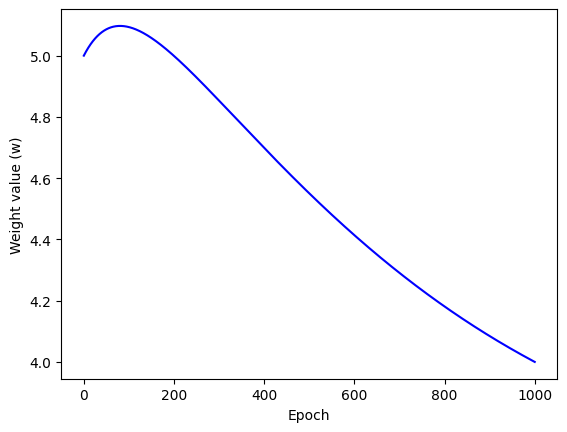

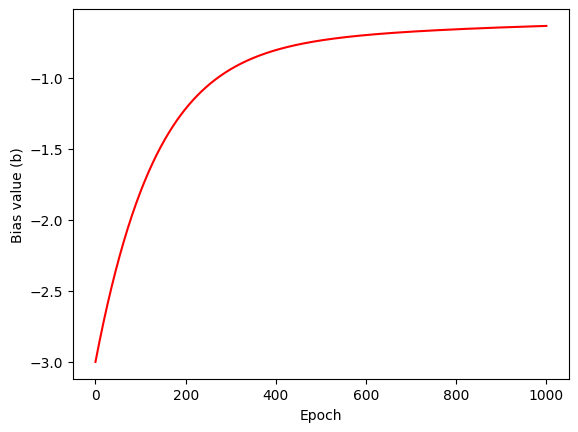

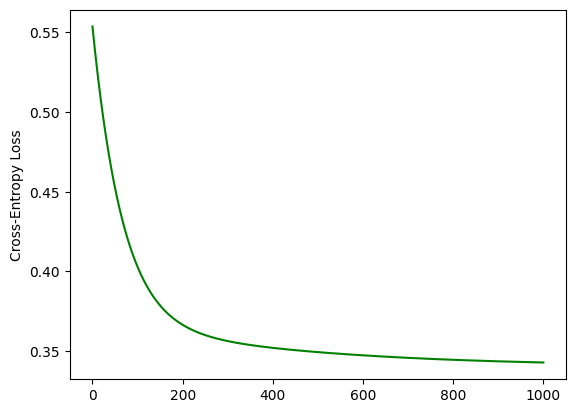

Predictive function after gradient descent: y = 1 / (1 + exp(4.0000 * X + -0.6341))
Cross-Entropy Loss: 0.3428


In [23]:
# Initial weight, bias values
w = 5
b = -3
gamma = 0.1 # Learning rate

steps_w = [w]
steps_b = [b]
losses = [compute_cross_entropy_loss(X, y, w, b)]

for epoch in range(1000):
  dw, db = compute_gradients(X, y, w, b) # Get the derivatives, assign to db, dw
  w = w - gamma * dw  # Update the weight
  b = b - gamma * db  # Update the bias

  loss = compute_cross_entropy_loss(X, y, w, b) # Compute the current loss
  losses.append(loss) # Append to the loss 'history'
  steps_w.append(w) # Append to the weight 'history'
  steps_b.append(b) # Append to the bias 'history'

  if epoch % 100 == 0:
    print(f'Epoch {epoch}')
    print(f'Current loss: {loss:.4f}')
    print(f'Current w and b: w = {w:.4f}, b = {b:.4f}')


plt.plot(range(1001), steps_w, color='blue')
plt.xlabel('Epoch')
plt.ylabel('Weight value (w)')
plt.show()

plt.plot(range(1001), steps_b, color='red')
plt.xlabel('Epoch')
plt.ylabel('Bias value (b)')
plt.show()

plt.plot(range(1001), losses, color='green')
plt.ylabel('Cross-Entropy Loss')
plt.show()


print(f"Predictive function after gradient descent: y = 1 / (1 + exp({w:.4f} * X + {b:.4f}))")
print(f'Cross-Entropy Loss: {compute_cross_entropy_loss(X, y, w, b):.4f}')

In [16]:
X_sorted = np.sort(X)

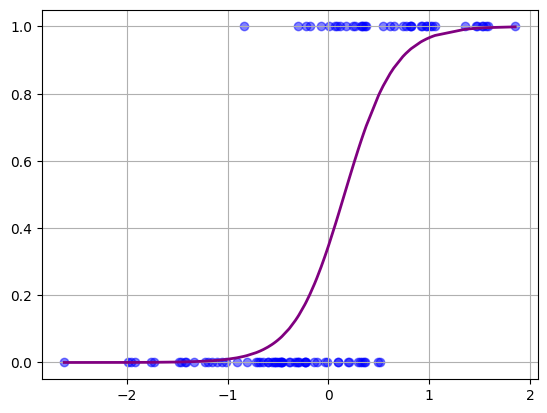

In [22]:
# Plot the prediction
plt.plot(X_sorted, sigmoid(w * X_sorted + b), color='purple', linewidth=2.0)
plt.scatter(X, y, color='blue', alpha=0.5)
plt.grid()
plt.show()